# Coca Supply Shocks and Violence in Colombia
## Difference-in-differences and identification diagnostics

**Contributors:** Jonathan Sauer, Muhammad Murodzoda, Sebastian Aguilar  
**Portfolio presentation:** Muhammad Murodzoda

This case study examines whether coca-growing departments experienced a larger change in a population-normalized violence outcome than comparison departments. It combines a difference-in-differences estimate with descriptive exploration, pre-trend diagnostics, a pre-period placebo, and covariate-adjusted regressions.

The project adapts a collaborative university analysis associated with Angrist and Kugler (2008). It is not an exact replication of their published tables. **All original code cells, code comments, execution counts, and saved outputs are preserved. Only the Markdown narrative has been edited; no cells were rerun.**

## 1. Research design and data construction

The research question is whether the change in recorded violence differs between coca-growing and comparison departments following the disruption of the coca supply route.

The analysis retains **1991–1993** as the pre-period and **1996–1998** as the post-period. The original study describes disruption beginning in 1994; the selected post-period measures a later window rather than the event date itself.

- `grow`: indicator for nine department codes classified as coca-growing in the analysis.
- `after`: indicator for the selected post-period.
- `growafter`: the exposure-by-post interaction.
- `outcome`: `log(violent_ + 1) - log(populati + 1)`.

Rows represent department–year–age-code–sex-code cells, not individual respondents. Age is coded categorically in the source data. The supplied population denominator is repeated across matched male/female cells, so the outcome is described here as a **log-smoothed population-normalized violence measure**, not a verified sex-specific mortality rate.

Identification relies on parallel counterfactual trends, no relevant anticipation, no differential concurrent shocks, and sufficiently stable measurement and composition. Spillovers into comparison regions are another potential threat.

In [1]:
# all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.formula.api as smf


In [5]:
warnings.filterwarnings("ignore")


In [6]:
data = pd.read_csv('data00_AngristKugler.tab', sep='\t') # reading data
data['grow'] = data['dep_ocu'].isin([13, 18, 19, 50, 52, 86, 95, 97, 99]).astype(int) # creating grow variable
data['outcome'] = np.log(data['violent_'] + 1) - np.log(data['populati'] + 1)
data = data[data['year'].isin([1991, 1992, 1993, 1996, 1997, 1998])]
data['after'] = data['year'].isin([1996, 1997, 1998]).astype(int) # creating after variable
data['growafter'] = data['grow'] * data['after'] # creating growafter variable
print('All coca-growing regions:', data[data['grow'] == 1]['dep_ocu'].unique())  # confirmed that 1 in coca-growing regions
print('Post bridge-dirsuption:', data[data['after'] == 1]['year'].unique())  # confirmed that 1 in years after bridge-disruption


All coca-growing regions: [13 18 19 50 52 86 95 97 99]
Post bridge-dirsuption: [1996 1997 1998]


## 2. Distributional patterns before and after

The first pair of density plots compares the outcome distributions before and after within each exposure group. The second set separates the observations by sex code.

These figures describe the distribution and spread of recorded outcomes. A rightward shift corresponds to higher values of the transformed measure. Density height is not a count of deaths, and distributional shifts alone do not establish a treatment effect. The subsequent DiD comparison accounts for changes in the comparison group.

Sex-specific patterns should also be interpreted with the supplied denominator limitation in mind; these plots do not directly establish differences in individual mortality risk.

<Figure size 1200x600 with 0 Axes>

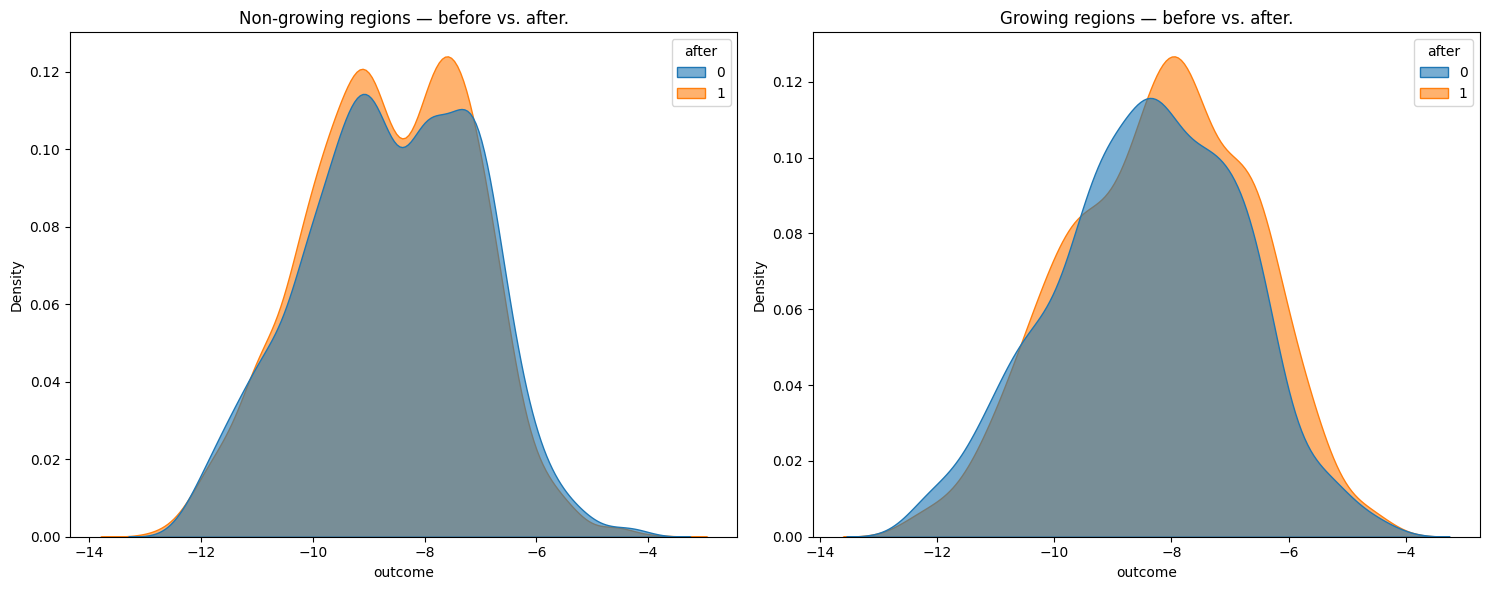

In [7]:
data_non_growing = data[data['grow'] == 0]
data_growing = data[data['grow'] == 1]

plt.figure(figsize=(12, 6))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# left density plot
sns.kdeplot(data=data_non_growing, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax1)
ax1.set_title('Non-growing regions — before vs. after.')

# right density plot
sns.kdeplot(data=data_growing, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax2)
ax2.set_title('Growing regions — before vs. after.')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

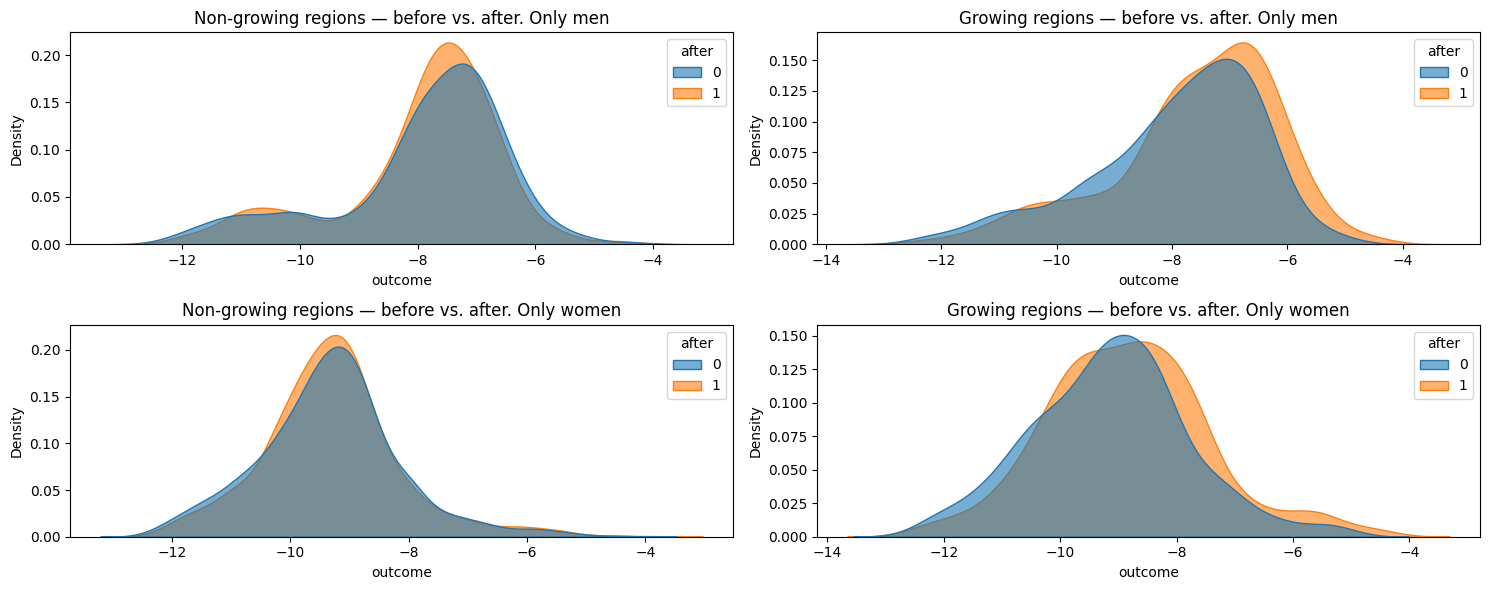

In [8]:
data_non_growing_men = data[(data['grow'] == 0) & (data['sex'] == 1)]
data_non_growing_women = data[(data['grow'] == 0) & (data['sex'] == 2)]

data_growing_men = data[(data['grow'] == 1) & (data['sex'] == 1)]
data_growing_women = data[(data['grow'] == 1) & (data['sex'] == 2)]


plt.figure(figsize=(12, 6))

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 6))

# left top density plot
sns.kdeplot(data=data_non_growing_men, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax1[0])
ax1[0].set_title('Non-growing regions — before vs. after. Only men')

# left bottom density plot
sns.kdeplot(data=data_non_growing_women, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax2[0])
ax2[0].set_title('Non-growing regions — before vs. after. Only women')

# right top density plot
sns.kdeplot(data=data_growing_men, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax1[1])
ax1[1].set_title('Growing regions — before vs. after. Only men')

# right bottom density plot
sns.kdeplot(data=data_growing_women, x='outcome', hue='after', fill=True, alpha=0.6, ax=ax2[1])
ax2[1].set_title('Growing regions — before vs. after. Only women')

plt.tight_layout()
plt.show()

## 3. Before–after changes by age category

For coca-growing departments, the following plot calculates

$$\Delta_a=\overline{Y}_{a,post}-\overline{Y}_{a,pre}.$$

This is a descriptive before–after comparison within the exposed group, not an age-specific DiD: no comparison-group change is subtracted. The x-axis contains **age-category codes**, not literal ages. Without a validated mapping, the plotted codes should not be labeled as children, teenagers, or adult age ranges.

<Axes: xlabel='age', ylabel='outcome'>

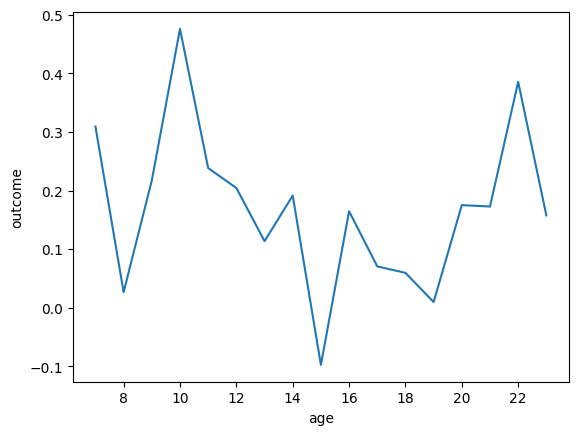

In [9]:
data_growing_before = data_growing[data_growing['after'] == 0]
data_growing_after = data_growing[data_growing['after'] == 1]

#calculate the difference in means by age
delta_ages = data_growing_after[['age', 'outcome']].groupby('age').mean() - data_growing_before[['age', 'outcome']].groupby('age').mean()
sns.lineplot(data=delta_ages.reset_index(), x='age', y='outcome')


## 4. Pre-treatment trend diagnostics

The code uses **1991–1993**, the pre-period retained in the main data frame. It estimates a differential linear trend and a categorical-year model with 1991 as reference, then plots group means with the original confidence bands.

Saved interaction p-values are **0.9794** for the linear trend and **0.8452** and **0.9810** for 1992 and 1993. These tests do not detect differential pre-trends. However, three years offer limited evidence, and failure to reject is not proof of parallel counterfactual trends.

The categorical model reports **individual interaction tests**, not a joint test. The plotted confidence bands and OLS p-values are not adjusted for dependence within departments. Overlapping bands do not themselves test equality of trends.

In [10]:
# Linear trend
pre_treatment_data = data[data['after'] == 0]
model_linear = smf.ols('outcome ~ year + grow + year:grow', data=pre_treatment_data).fit()
print(model_linear.summary())

#pvalue
print(f"\nP-value for linear year interaction: {model_linear.pvalues['year:grow']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.911
Date:                Sun, 26 Oct 2025   Prob (F-statistic):             0.0332
Time:                        20:17:52   Log-Likelihood:                -5847.9
No. Observations:                3167   AIC:                         1.170e+04
Df Residuals:                    3163   BIC:                         1.173e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.4860     77.022      0.058      0.9

In [11]:
# Categorical variable - year
pre_treatment_data = data[data['after'] == 0]

pre_treatment_data_cat = pd.get_dummies(pre_treatment_data, columns=['year'], prefix='year', drop_first=True) # base year = 1991


model_categ = smf.ols('outcome ~ year_1992 + year_1993 + grow + year_1992:grow + year_1993:grow', data=pre_treatment_data_cat).fit()
print(model_categ.summary())

#pvalue
print(f"\nP-value for categorical year_1992 interaction: {model_categ.pvalues['year_1992[T.True]:grow']:.4f}")
print(f"\nP-value for categorical year_1993 interaction: {model_categ.pvalues['year_1993[T.True]:grow']:.4f}")

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.841
Date:                Sun, 26 Oct 2025   Prob (F-statistic):              0.101
Time:                        20:17:52   Log-Likelihood:                -5847.6
No. Observations:                3167   AIC:                         1.171e+04
Df Residuals:                    3161   BIC:                         1.174e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -8

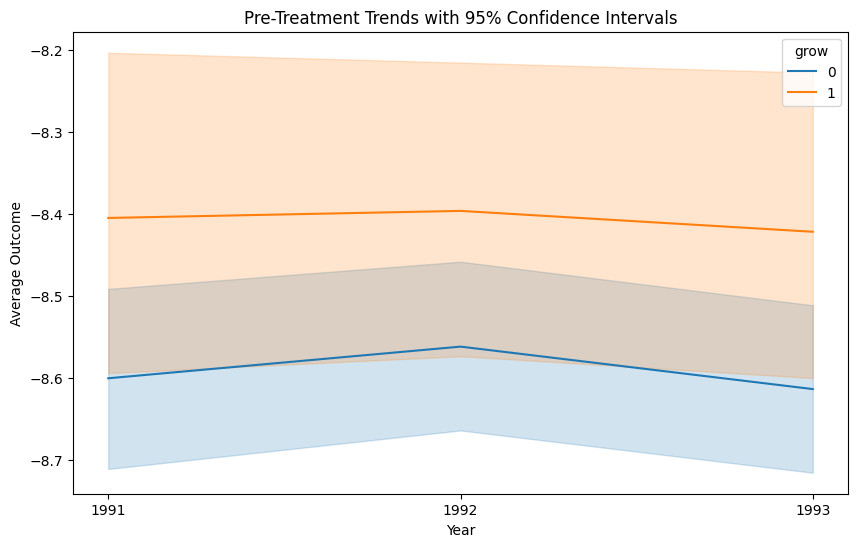

In [12]:
# Convert year to categorical
pre_treatment_data['year'] = pre_treatment_data['year'].astype('string')

plt.figure(figsize=(10, 6))
sns.lineplot(data=pre_treatment_data, x='year', y='outcome', hue='grow',
             err_style='band', errorbar=('ci', 95))
plt.xlabel('Year')
plt.ylabel('Average Outcome')
plt.title('Pre-Treatment Trends with 95% Confidence Intervals')
plt.show()

## 5. Pre-period placebo test

This diagnostic uses **1990–1993** and assigns **1992–1993** to a false post-period, with 1990–1991 as the comparison period. Its interaction asks whether a differential change appears before the actual disruption.

The saved placebo coefficient is approximately **−0.0124**, with **p = 0.909** under conventional OLS inference. There is no statistically detectable placebo contrast in this specification. This is a useful falsification check, but it does not demonstrate that there were no pre-existing differences or that all confounders have been removed.

In [13]:
placebo_data =  pd.read_csv('data00_AngristKugler.tab', sep='\t') # reading data
placebo_data['grow'] = placebo_data['dep_ocu'].isin([13, 18, 19, 50, 52, 86, 95, 97, 99]).astype(int) # creating grow variable
placebo_data['outcome'] = np.log(placebo_data['violent_'] + 1) - np.log(placebo_data['populati'] + 1)
placebo_data = placebo_data[placebo_data['year'].isin([1990, 1991, 1992, 1993])]
placebo_data['placebo_after'] = placebo_data['year'].isin([1992, 1993]).astype(int) # creating placebo_after variable
placebo_data['grow_placebo_after'] = placebo_data['grow'] * placebo_data['placebo_after'] # creating growafter variable


model_placebo = smf.ols('outcome ~ placebo_after + grow + grow_placebo_after', data=placebo_data).fit()
print(model_placebo.summary())


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.924
Date:                Sun, 26 Oct 2025   Prob (F-statistic):            0.00827
Time:                        20:17:53   Log-Likelihood:                -7810.1
No. Observations:                4225   AIC:                         1.563e+04
Df Residuals:                    4221   BIC:                         1.565e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -8.6089      0

## 6. Baseline group composition

The table compares pre-period means of the supplied age code, sex code, and population field. The clearest numerical difference is the mean supplied population: approximately **78,301** for comparison cells versus **40,541** for coca-growing cells.

Means of category codes are not average ages or direct population composition measures. This table is descriptive; it is not a standardized balance assessment. DiD does not require identical baseline levels, but group differences warrant attention if they may also generate different trends.

In [14]:
pre_treatment_data[['grow', 'age', 'sex', 'populati']].groupby('grow').mean()

,age,sex,populati
grow,,,
0,15.560016,1.511040,78300.870354
1,15.462441,1.591549,40540.899108


### What baseline comparisons can establish

Similar observed covariates do not establish random assignment or remove unobserved confounding. Conversely, different baseline outcome levels are compatible with DiD when counterfactual trends are parallel.

Appropriate pre-treatment covariates can account for measured differences or improve precision, but adding them does not automatically repair a weak identification strategy. If violence would already have evolved differently between groups, DiD can attribute that differential evolution to the exposure.

### Covariate timing and post-treatment adjustment

Covariates measured before exposure are generally easier to justify than variables that may themselves respond to it. Population, for example, can change through migration or displacement and already appears in the outcome's denominator.

Conditioning on a post-treatment mediator can block part of the effect of interest; conditioning on a collider can introduce bias. Merely adding such a variable does not identify a controlled direct effect without further assumptions. The later population-adjusted regression is therefore treated as an alternative association, not automatically as a superior causal estimate.

## 7. The difference-in-differences contrast

The four group-period means define

$$\widehat\tau=(\bar Y_{1,post}-\bar Y_{1,pre})-(\bar Y_{0,post}-\bar Y_{0,pre}).$$

The saved table reports a change of **0.192623** in coca-growing cells and **−0.059977** in comparison cells, yielding **0.252600 log points**.

In [ ]:
data = pd.read_csv("data00_AngristKugler.tab", sep="\t")
data["grow"] = data["dep_ocu"].isin([13,18,19,50,52,86,95,97,99]).astype(int)
data["outcome"] = np.log(data["violent_"] + 1) - np.log(data["populati"] + 1)
data = data[data["year"].isin([1991,1992,1993,1996,1997,1998])].copy()
data["after"] = data["year"].isin([1996,1997,1998]).astype(int)

Y00 = data.query("grow==0 and after==0")["outcome"].mean()
Y10 = data.query("grow==1 and after==0")["outcome"].mean()
Y01 = data.query("grow==0 and after==1")["outcome"].mean()
Y11 = data.query("grow==1 and after==1")["outcome"].mean()

chg_g1 = Y11 - Y10
chg_g0 = Y01 - Y00
DiD = chg_g1 - chg_g0

print("### Difference-in-Differences Summary\n")
print("| Group  | Before (Y·0) | After (Y·1) | Change |")
print("|:------ | ------------:| -----------:| ------:|")
print(f"| grow=1 | {Y10:.6f}      | {Y11:.6f}     | {chg_g1:.6f} |")
print(f"| grow=0 | {Y00:.6f}      | {Y01:.6f}     | {chg_g0:.6f} |\n")
print(f"**DiD = {DiD:.6f}**  (units: log-rate)")

### Difference-in-Differences Summary

| Group  | Before (Y·0) | After (Y·1) | Change |
|:------ | ------------:| -----------:| ------:|
| grow=1 | -8.407476      | -8.214853     | 0.192623 |
| grow=0 | -8.591773      | -8.651750     | -0.059977 |

**DiD = 0.252600**  (units: log-rate)


DiD subtracts the comparison group's change from the exposed group's change. This removes common changes and time-invariant group-level differences in the simple two-by-two setup. It does not remove differential time-varying shocks. A causal interpretation therefore remains conditional on the design assumptions.

## 8. Regression-based DiD

The pooled regression estimates the exposure-by-post interaction alongside exposure and period indicators:

$$Y=\beta_0+\beta_1 Post+\beta_2 Grow+\beta_3(Grow\times Post)+u.$$

The saved output below is retained from the original notebook. **Execution note:** the preceding section reloads `data` without recreating `growafter`, so the original code has a top-to-bottom execution dependency at this regression. This presentation-only revision documents that issue without changing code or rerunning outputs.

In [ ]:
model = smf.ols('outcome ~ after + grow + growafter', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     20.51
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.19e-13
Time:                        21:43:27   Log-Likelihood:                -11836.
No. Observations:                6449   AIC:                         2.368e+04
Df Residuals:                    6445   BIC:                         2.371e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.5918      0.031   -275.022      0.0

The saved interaction estimate is **0.2526**, with conventional OLS **p = 0.003** (rounded) and a 95% interval of approximately **[0.083, 0.422]**.

The exposed group's transformed outcome increased by about **0.253 log points more** than the comparison group's outcome in the selected windows. This is not a percentage-point increase or a count of additional deaths. The pseudocount transformation and uncertain denominator prevent a direct interpretation as an individual mortality-risk percentage.

The saved model uses **nonrobust standard errors**, not department-clustered inference. Its reported statistical significance should therefore not be presented as evidence that accounts for within-department dependence. The following direct calculation reproduces the stored four-mean contrast.

In [ ]:
Y00bar = data.query("grow == 0 and after == 0")["outcome"].mean()
Y10bar = data.query("grow == 1 and after == 0")["outcome"].mean()
Y01bar =  data.query("grow == 0 and after == 1")["outcome"].mean()
Y11bar = data.query("grow == 1 and after == 1")["outcome"].mean()
DiD = (Y11bar - Y10bar) - (Y01bar - Y00bar)
print(DiD)

0.2525998479570948


## 9. Covariate-adjusted specifications

The next two stored regressions add age and sex codes, followed by the supplied population field. The original code treats the age and sex fields numerically. These are alternative pooled specifications; they do not include department or year fixed effects beyond the two-period indicator.

In [ ]:
model = smf.ols('outcome ~ after + grow + growafter + age + sex', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     739.7
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:57:22   Log-Likelihood:                -10404.
No. Observations:                6449   AIC:                         2.082e+04
Df Residuals:                    6443   BIC:                         2.086e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.1197      0.067   -135.495      0.0

In [ ]:
model = smf.ols('outcome ~ after + grow + growafter + age + sex + populati', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     633.8
Date:                Tue, 21 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:57:44   Log-Likelihood:                -10371.
No. Observations:                6449   AIC:                         2.076e+04
Df Residuals:                    6442   BIC:                         2.080e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.8152      0.077   -114.968      0.0

The saved interaction estimates are:

| Specification | DiD coefficient | Conventional p-value |
|---|---:|---:|
| Exposure and period indicators | 0.2526 | 0.003 |
| Add age and sex codes | 0.1869 | 0.007 |
| Also add supplied population | 0.1808 | 0.009 |

The positive coefficient becomes smaller after adjustment. This alone does not establish omitted-variable bias in the baseline or show that adjustment removes bias. Numeric treatment of age codes imposes a restrictive functional form, and contemporaneous population may be affected by the exposure. All reported p-values use the original nonrobust inference.

## 10. Findings and limitations

The saved analysis shows a **positive differential change** in the log-smoothed violence outcome for coca-growing departments. Its point estimate ranges from **0.1808 to 0.2526** across the three pooled specifications. The pre-trend and placebo diagnostics do not reject their null hypotheses under the original inference.

These patterns are compatible with a resource-curse interpretation, but they do not establish the mechanism or rule out competing explanations. The strongest transferable lesson is how to structure a nonrandomized comparison and critically assess its assumptions.

### Limits of the current analysis

- Conventional OLS standard errors do not address within-department dependence.
- A small number of pre-treatment years limits the power of trend diagnostics.
- Missing denominators and changes in available demographic cells may affect composition.
- Age codes and the repeated population denominator constrain demographic and mortality-risk interpretations.
- Population adjustment can introduce post-treatment concerns; additional regional confounders are not observed here.
- The saved notebook includes an execution-order dependency documented above. This revision preserves all original code and outputs rather than repairing or rerunning them.

### Possible future extensions—not implemented here

Department-clustered inference, categorical demographic controls, department and year fixed effects, a joint pre-trend test, dynamic year interactions, validated population denominators, and formal sensitivity checks could strengthen a subsequent version.

### Source and credits

Angrist, J. D., and Kugler, A. D. (2008). *Rural Windfall or a New Resource Curse? Coca, Income, and Civil Conflict in Colombia.* Review of Economics and Statistics, 90(2), 191–215. [Paper](https://economics.mit.edu/sites/default/files/publications/AK2008_corrected.pdf) · [Data archive](https://economics.mit.edu/people/faculty/josh-angrist/angrist-data-archive).

Original collaborative analysis: **Jonathan Sauer, Muhammad Murodzoda, and Sebastian Aguilar**. Portfolio narrative prepared for Muhammad Murodzoda. The research design and source data are attributed to their original authors.